Conditional Edges in graph

In [1]:
%pip install --quiet -U langgraph>=1.0.0


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from IPython.display import Image, display
from typing import  List,  TypedDict, Annotated,operator, Literal
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import InMemorySaver # in memeory db to save the state of graph [sqllite, postgressdb]
from langgraph.types import Command 

## Setup Langsmith

1. create an account on [Langsmith](https://smith.langchain.com/)
2. create a project and get the API key
3. set the API key as an environment variable in .env file with below values

```bash 
LANGSMITH_TRACING=true
LANGSMITH_ENDPOINT=https://api.smith.langchain.com
LANGSMITH_API_KEY="<your_api_key>"
LANGSMITH_PROJECT="ellucian"
```

In [ ]:

import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_TRACING"] = os.getenv("LANGSMITH_TRACING", "true")
os.environ["LANGSMITH_ENDPOINT"] = os.getenv("LANGSMITH_ENDPOINT", "https://api.smith.langchain.com")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY", "")
os.environ["LANGSMITH_PROJECT"] = os.getenv("LANGSMITH_PROJECT", "ellucian")

In [4]:
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]

In [5]:
def node_a(state: State) -> Command[Literal['b', 'c', END]]: # existing node names
    slected_node = state['nlist'][-1]  # Get the last added node
    next_node = ''
    if slected_node == 'b':
        next_node = 'b'
    elif slected_node == 'c':
        next_node = 'c'
    else:
       next_node = END

    return Command(
        update= State(nlist=["A Output: "+next_node]),
        goto = next_node
    )
    
def node_b(state: State) -> State:
    print(f"'B' Called: {state['nlist']}")
    return(State(nlist = ['B Output']))
def node_c(state: State) -> State:
    print(f"'C' Called: {state['nlist']}")
    return(State(nlist = ['C Output']))



In [ ]:
#def conditional_edge(state: State) -> Literal['b', 'c', END]: # existing nodes
#    slected_node = state['nlist'][-1]  # Get the last added node
#    if slected_node == 'b':
#        return 'b'
#    elif slected_node == 'c':
#        return 'c'
#    else:
#       return END

In [6]:
builder = StateGraph(State)

builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

builder.add_edge(START, "a")
# Normal edges [Static]
#builder.add_edge("a", "b")
#builder.add_edge("a", "c")
# Conditional edges [Dynamic _ Old way]
# builder.add_conditional_edges("a", conditional_edge)
builder.add_edge("b", END)
builder.add_edge("c", END)

# include memory to save the state of graph
memory = InMemorySaver()    
config = {"configurable": {"thread_id": "1"}}

graph = builder.compile(checkpointer=memory)


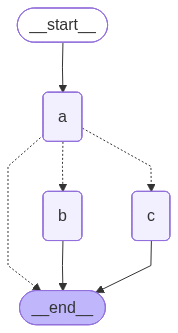

In [7]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
while True:
    user_propmpt = input("Enter a node name to start (b/c): ")
    print(f"User Input: {user_propmpt}")
    input_state = State(
        nlist = [user_propmpt]
    )
    # thread id will be configured for managing the user specific state in memory
    result = graph.invoke(input_state, config)
    print(result)
    if user_propmpt == 'q':
        print("quiting...")
        break

User Input: b
'B' Called: ['b', 'A Output: b']
{'nlist': ['b', 'A Output: b', 'B Output']}
User Input: c
'C' Called: ['b', 'A Output: b', 'B Output', 'c', 'A Output: c']
{'nlist': ['b', 'A Output: b', 'B Output', 'c', 'A Output: c', 'C Output']}
User Input: q
{'nlist': ['b', 'A Output: b', 'B Output', 'c', 'A Output: c', 'C Output', 'q', 'A Output: __end__']}
quiting...


In [ ]:
#  User Input: b
#  'B' Called: ['b', 'A Output: b']
#  {'nlist': ['b', 'A Output: b', 'B Output']}
#  User Input: c
#  'C' Called: ['c', 'A Output: c']
#  {'nlist': ['c', 'A Output: c', 'C Output']}
#  User Input: q
#  {'nlist': ['q', 'A Output: __end__']}
#  quiting...

Memory need For your application

1. application is trying to run multiple times human in the loop and saying that my last outut is not refine 
2. if the graph is used by myltiple users then how to retain the state of each user